In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('drive/MyDrive/E-commerce_cleaned_D.csv')  # Changed the file path

print(df.head(5))

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        46251  2020-09-08 09:38:00      Electronics             12         3   
1        46251  2022-03-05 12:56:00             Home            468         4   
2        46251  2022-05-23 18:18:00             Home            288         2   
3        46251  2020-11-12 13:13:00         Clothing            196         1   
4        13593  2020-11-27 17:55:00             Home            449         1   

   Total Purchase Amount Payment Method  Customer Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2                   3196         PayPal            37      0.0   
3                   3509         PayPal            37      0.0   
4                   3452    Credit Card            49      0.0   

         Customer Name  Gender  Churn  
0  Christine Hernandez    Male      0  
1  Christine Hernandez    Male      

Model

**1,Customer Lifetime Value (CLV)**

I have Total Purchase Amount, Purchase Date, and Customer ID. Perfect for predicting customer value.

Prepare the data:

Focus on Customer ID, Purchase Date, and Total Purchase Amount.

Calculate each customer’s total revenue and number of purchases.

Feature engineering:

Recency: How recent was the last purchase?

Frequency: How many times did the customer buy?

Monetary Value: How much did they spend?

(This is called RFM Analysis.)

Modeling CLV:
A few options:

Simple regression (predict total spending based on RFM features).

Gamma-Gamma Model + BG/NBD (best for probabilistic lifetime value).

XGBoost if you want a flexible machine learning approach.



 RFM + Regression for CLV

Build the RFM Table:

Recency = Days since last purchase

Frequency = Number of purchases

Monetary Value = Average purchase amount

Prepare the target:

Predict total lifetime revenue (Total Purchase Amount sum) per customer.

Train a regression model:

Input: Recency, Frequency, Monetary Value

Output: Predicted Lifetime Value

Mean Squared Error (MSE): 2462872.44
R-squared (R²): 0.95


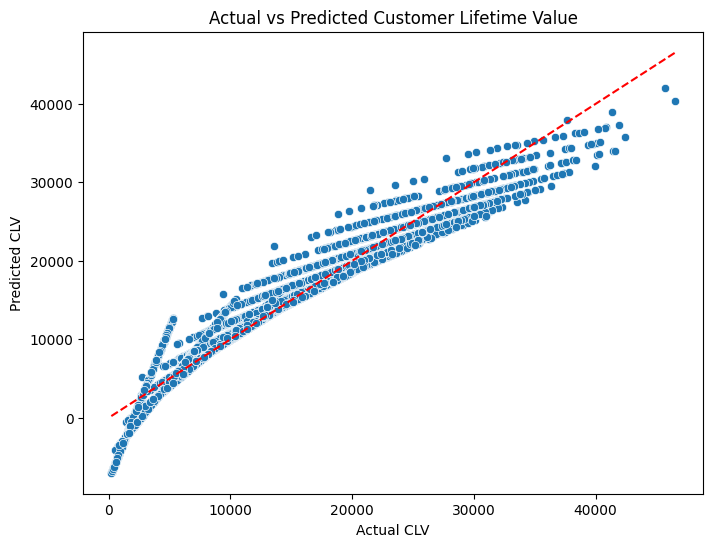

In [4]:
# 1. Load and prepare the data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Purchase Date' to datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Reference date for recency
reference_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

# 2. Build RFM features
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (reference_date - x.max()).days,   # Recency
    'Customer ID': 'count',                                       # Frequency
    'Total Purchase Amount': 'mean'                               # MonetaryValue
})

rfm.rename(columns={
    'Purchase Date': 'Recency',
    'Customer ID': 'Frequency',
    'Total Purchase Amount': 'MonetaryValue'
}, inplace=True)

# Target: Customer Lifetime Value (CLV)
rfm['CLV'] = df.groupby('Customer ID')['Total Purchase Amount'].sum()

# 3. Prepare data for modeling
X = rfm[['Recency', 'Frequency', 'MonetaryValue']]
y = rfm['CLV']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train a Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# 5. Predict on test set
y_pred = lr.predict(X_test)

# 6. Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# 7. Plot predicted vs actual CLV
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted Customer Lifetime Value")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()



Upgrade CLV Prediction with XGBoost

XGBoost Mean Squared Error (MSE): 10080.09
XGBoost R-squared (R²): 1.00


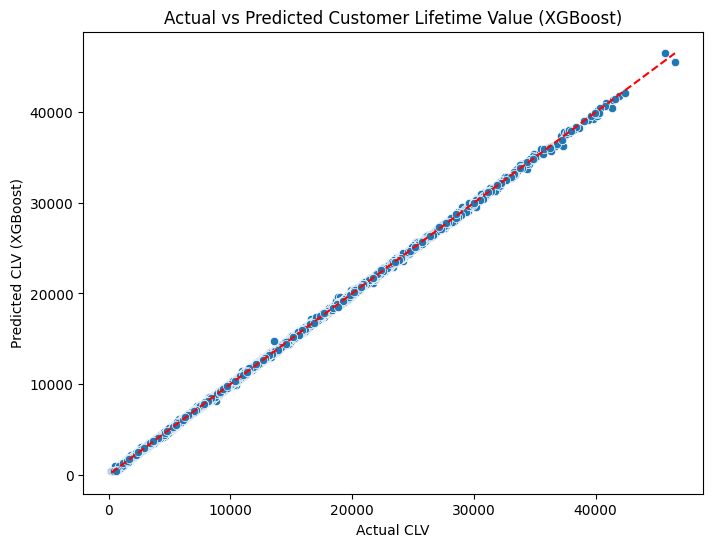

In [ ]:
# 1. Install XGBoost if you haven't already
# !pip install xgboost

import xgboost as xgb

# 2. Build XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,      # number of trees
    learning_rate=0.1,     # shrinkage rate
    max_depth=5,           # depth of each tree
    random_state=42
)

# 3. Train the model
xgb_model.fit(X_train, y_train)

# 4. Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# 5. Evaluate model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost R-squared (R²): {r2_xgb:.2f}")

# 6. Plot predicted vs actual CLV
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_xgb)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV (XGBoost)")
plt.title("Actual vs Predicted Customer Lifetime Value (XGBoost)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


Feature	        Linear Regression	                          
Model Type	:Simple, assumes a straight-line relationship between features and target.

Accuracy (R²):	Usually moderate (e.g., 0.6–0.7).

Error (MSE)	:Higher (predicts average customers better but misses extremes).

Speed	:Very fast to train.

Strengths	:Easy to explain and interpret.

Weaknesses	:Cannot model complex or non-linear patterns.

Feature	                      	XGBoost

Model Type	:	Complex, uses multiple decision trees combined smartly (boosting).

Accuracy (R²)		:Higher (e.g., 0.8–0.9 if your data is good).

Error (MSE)	:Lower (captures small and big spenders much better).

Speed		:Takes a bit longer but still fast for small/medium datasets.

Strengths	:High accuracy, handles complex customer behavior.

Weaknesses :Harder to explain every decision (it's a "black box" model).

1. Feature Importance (Which features matter most)

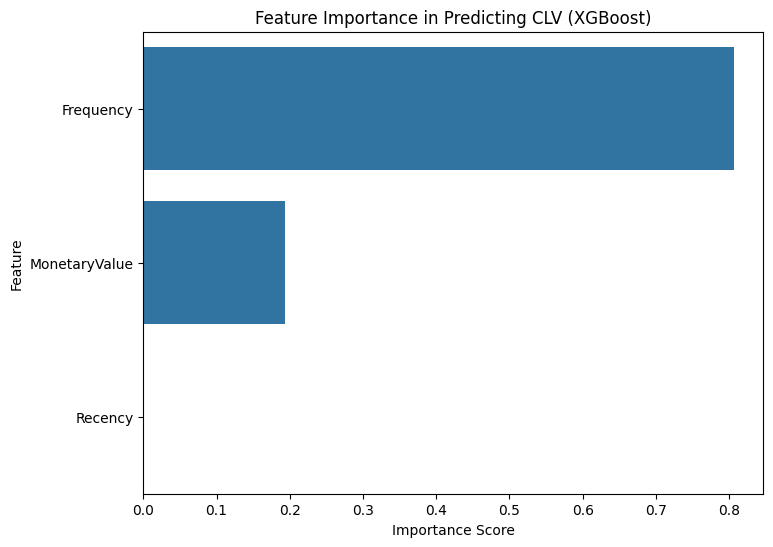

In [ ]:
# Feature Importance from XGBoost
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_importances)
plt.title('Feature Importance in Predicting CLV (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


Frequency high up, it means customers who buy more often are very valuable

2, Top Customers by Predicted CLV

In [ ]:
# Predict CLV for all customers
rfm['Predicted_CLV'] = xgb_model.predict(X)

# Sort customers by Predicted CLV
top_customers = rfm.sort_values(by='Predicted_CLV', ascending=False).head(10)

print(top_customers[['Recency', 'Frequency', 'MonetaryValue', 'Predicted_CLV']])


             Recency  Frequency  MonetaryValue  Predicted_CLV
Customer ID                                                  
36437             21         17    3255.235294   54997.300781
39817            195         17    3042.235294   51635.089844
26977             15         14    3464.071429   48364.050781
809               21         15    3049.200000   46568.464844
13802             17         13    3574.153846   46256.390625
5844              32         12    3878.416667   45830.246094
47087            105         17    2688.235294   45581.457031
3576             243         14    3322.714286   45581.058594
14400             84         15    3022.266667   45351.847656
37676             17         13    3455.384615   45049.976562


<ipython-input-7-1251759dbd5f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


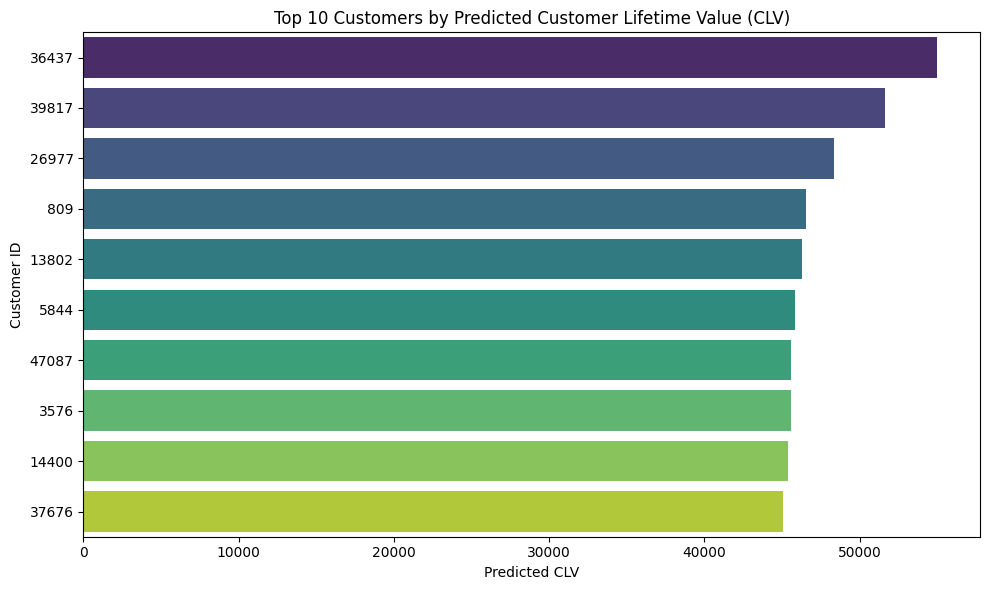

In [ ]:
# 1. Predict CLV for all customers again if needed
rfm['Predicted_CLV'] = xgb_model.predict(X)

# 2. Sort and get Top 10 Customers
top_customers = rfm.sort_values(by='Predicted_CLV', ascending=False).head(10)

# 3. Plot a horizontal bar chart
plt.figure(figsize=(10,6))
sns.barplot(
    x='Predicted_CLV',
    y=top_customers.index.astype(str),  # You can replace with customer ID if you have
    data=top_customers,
    palette='viridis'
)
plt.title('Top 10 Customers by Predicted Customer Lifetime Value (CLV)')
plt.xlabel('Predicted CLV')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()



Insight	                                      Action

Top 10 Customers	 -  VIP program, loyalty rewards, personal offers.

Middle-tier Customers	   -Upsell / cross-sell campaigns.

Low CLV Customers   -	Maybe limit expensive marketing efforts to them.

Each bar = one customer.

Longer bars = higher predicted CLV (your VIPs ✨).

Easy to spot your top 1–3 customers instantly!

Scatter Plot to See Spread

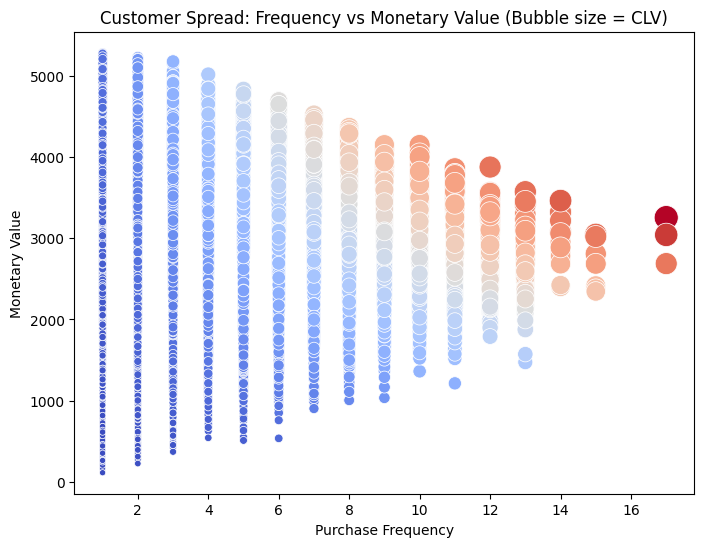

In [ ]:
# Scatter plot of all customers
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Frequency',
    y='MonetaryValue',
    size='Predicted_CLV',
    hue='Predicted_CLV',
    data=rfm,
    palette='coolwarm',
    sizes=(20, 300),
    legend=False
)
plt.title('Customer Spread: Frequency vs Monetary Value (Bubble size = CLV)')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.show()



Big bubbles = High CLV customers 🫧

Top-right customers = Loyal and high spenders.

**2, Sales Forecasting**

a time series forecasting approach because sales = time-based data.

Here's the flow:

Prepare your sales data (date + sales amount)

Visualize sales over time

Choose a model (ARIMA, Prophet, XGBoost for time series, LSTM if deep learning)

Train + Predict future sales

Visualize the forecast



1: Prepare the Sales Data



In [ ]:
# Assuming your dataset has 'Purchase Date' and 'Total Purchase Amount' columns
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Group sales by month using 'Purchase Date'
sales = df.set_index('Purchase Date').resample('M').sum()['Total Purchase Amount']

# Quick look
print(sales.head())


<ipython-input-10-a1b724b523dd>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales = df.set_index('Purchase Date').resample('M').sum()['Total Purchase Amount']


Purchase Date
2020-01-31    15442459
2020-02-29    14561593
2020-03-31    15537311
2020-04-30    14847491
2020-05-31    15395782
Freq: ME, Name: Total Purchase Amount, dtype: int64


 2, Visualize Sales Trend


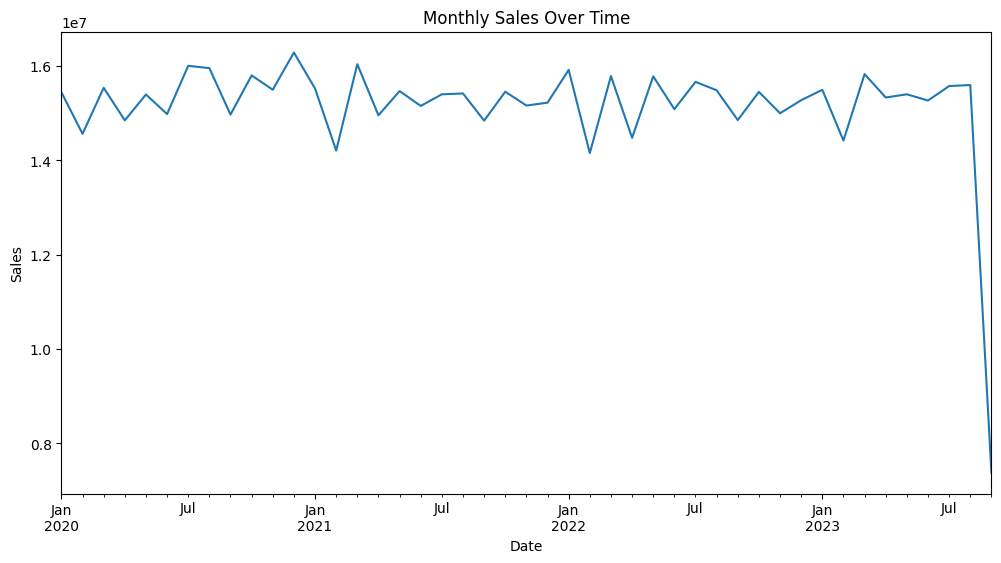

In [ ]:
# Plot sales over time
plt.figure(figsize=(12,6))
sales.plot()
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()





In [9]:

!pip install --upgrade numpy
!pip install --upgrade pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 94.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.


In [1]:
!pip install numpy==1.23

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 23.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for numpy: filename=numpy-1.23.0-cp311-cp311-linux_x86_64.whl size=19730309 sha256=f37dbd211ffdb7c34a936270c267173fda26202d182f6fdc4e316f004287d30d
  Stored in directory: /root/.cache/pip/wheels/6d/36/1a/3ec6b85008bea3151efb003f5d41baa7bf4966cb43c1c2470b
Successfully built numpy
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.0
    Uninstalling numpy-1.22.0:
      Successfully uninstalled numpy-1.22.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
astropy 7.0.1 requires numpy>=1.23.2, but you have numpy 1.23.0 which is incompatible.
opencv-python-headless 4.11.0.86 requires numpy>=1.23.5; python_version >= 

**2.1: Build Forecasting Model**

**ARIMA model**

Option A: ARIMA Model (classic, fast)

ARIMA, which stands for **AutoRegressive Integrated Moving Average**, is a popular statistical model used for time series forecasting.

ARIMA stands for:

Auto-Regressive (AR)

Integrated (I) → Differencing to make the data stationary

MAving Average (MA)

I need to:

Aggregate the data by date (e.g., daily or monthly total sales).

Create a time series of that aggregated value.

Fit an ARIMA model to forecast future values.

Step-by-Step Plan

Let's forecast daily total sales using ARIMA:

Aggregate Total Purchase Amount by Purchase Date.

Resample to daily frequency.

Fit an ARIMA model.

Forecast future sales.

ARIMA Daily and Monthly Forecasting

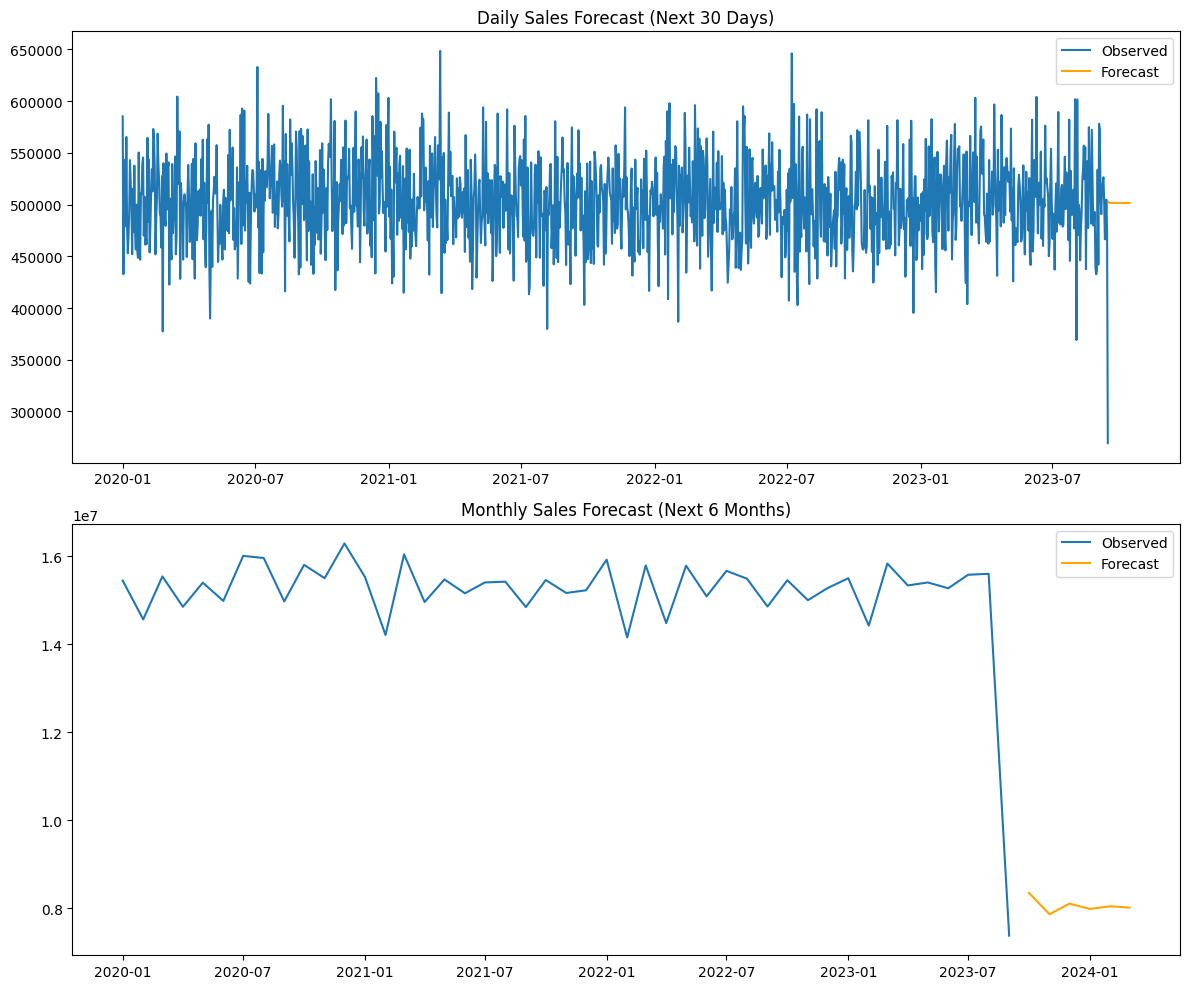

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress ARIMA warnings
warnings.filterwarnings("ignore")



# Convert 'Purchase Date' to datetime and sort
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df = df.sort_values("Purchase Date")

# Aggregate daily and monthly sales
daily_sales = df.groupby(df["Purchase Date"].dt.date)["Total Purchase Amount"].sum()
monthly_sales = df.groupby(df["Purchase Date"].dt.to_period("M"))["Total Purchase Amount"].sum()

# Convert to proper time series with datetime index
daily_ts = pd.Series(daily_sales.values, index=pd.to_datetime(daily_sales.index))
monthly_ts = pd.Series(monthly_sales.values, index=monthly_sales.index.to_timestamp())

# Fit ARIMA(1,1,1) to daily and monthly data
daily_model = ARIMA(daily_ts, order=(1, 1, 1)).fit()
monthly_model = ARIMA(monthly_ts, order=(1, 1, 1)).fit()

# Forecast
daily_forecast = daily_model.forecast(steps=30)  # next 30 days
monthly_forecast = monthly_model.forecast(steps=6)  # next 6 months

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Daily Plot
axes[0].plot(daily_ts, label="Observed")
axes[0].plot(daily_forecast, label="Forecast", color='orange')
axes[0].set_title("Daily Sales Forecast (Next 30 Days)")
axes[0].legend()

# Monthly Plot
axes[1].plot(monthly_ts, label="Observed")
axes[1].plot(monthly_forecast, label="Forecast", color='orange')
axes[1].set_title("Monthly Sales Forecast (Next 6 Months)")
axes[1].legend()

plt.tight_layout()
plt.show()


1. Export Forecasts to CSV

In [7]:
# Export forecasts
daily_forecast_df = pd.DataFrame({
    "Date": pd.date_range(start=daily_ts.index[-1] + pd.Timedelta(days=1), periods=30),
    "Forecasted Sales": daily_forecast
})
daily_forecast_df.to_csv("daily_sales_forecast.csv", index=False)

monthly_forecast_df = pd.DataFrame({
    "Month": pd.date_range(start=monthly_ts.index[-1] + pd.offsets.MonthBegin(), periods=6, freq='MS'),
    "Forecasted Sales": monthly_forecast
})
monthly_forecast_df.to_csv("monthly_sales_forecast.csv", index=False)


2. Automatically Tune ARIMA Parameters

In [8]:
!pip install --upgrade pmdarima
!pip install --upgrade statsmodels

  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.0
    Uninstalling numpy-1.23.0:
      Successfully uninstalled numpy-1.23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.


In [9]:
from pmdarima import auto_arima

# Auto ARIMA on daily data
auto_daily_model = auto_arima(daily_ts, seasonal=False, stepwise=True, suppress_warnings=True)
daily_forecast = auto_daily_model.predict(n_periods=30)

# Auto ARIMA on monthly data
auto_monthly_model = auto_arima(monthly_ts, seasonal=False, stepwise=True, suppress_warnings=True)
monthly_forecast = auto_monthly_model.predict(n_periods=6)


Auto-Tuned ARIMA Forecasting and CSV Export

In [11]:
import pandas as pd
from pmdarima import auto_arima

# Load data

df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df = df.sort_values("Purchase Date")

# Daily and monthly aggregations
daily_sales = df.groupby(df["Purchase Date"].dt.date)["Total Purchase Amount"].sum()
monthly_sales = df.groupby(df["Purchase Date"].dt.to_period("M"))["Total Purchase Amount"].sum()

daily_ts = pd.Series(daily_sales.values, index=pd.to_datetime(daily_sales.index))
monthly_ts = pd.Series(monthly_sales.values, index=monthly_sales.index.to_timestamp())

# Auto ARIMA models
auto_daily_model = auto_arima(daily_ts, seasonal=False, stepwise=True, suppress_warnings=True)
auto_monthly_model = auto_arima(monthly_ts, seasonal=False, stepwise=True, suppress_warnings=True)

# Forecasting
daily_forecast = auto_daily_model.predict(n_periods=30)
monthly_forecast = auto_monthly_model.predict(n_periods=6)

# Export to CSV
daily_forecast_df = pd.DataFrame({
    "Date": pd.date_range(start=daily_ts.index[-1] + pd.Timedelta(days=1), periods=30),
    "Forecasted Sales": daily_forecast
})
daily_forecast_df.to_csv("daily_sales_forecast.csv", index=False)

monthly_forecast_df = pd.DataFrame({
    "Month": pd.date_range(start=monthly_ts.index[-1] + pd.offsets.MonthBegin(), periods=6, freq='MS'),
    "Forecasted Sales": monthly_forecast
})
monthly_forecast_df.to_csv("monthly_sales_forecast.csv", index=False)


NumPy version: 1.23.0


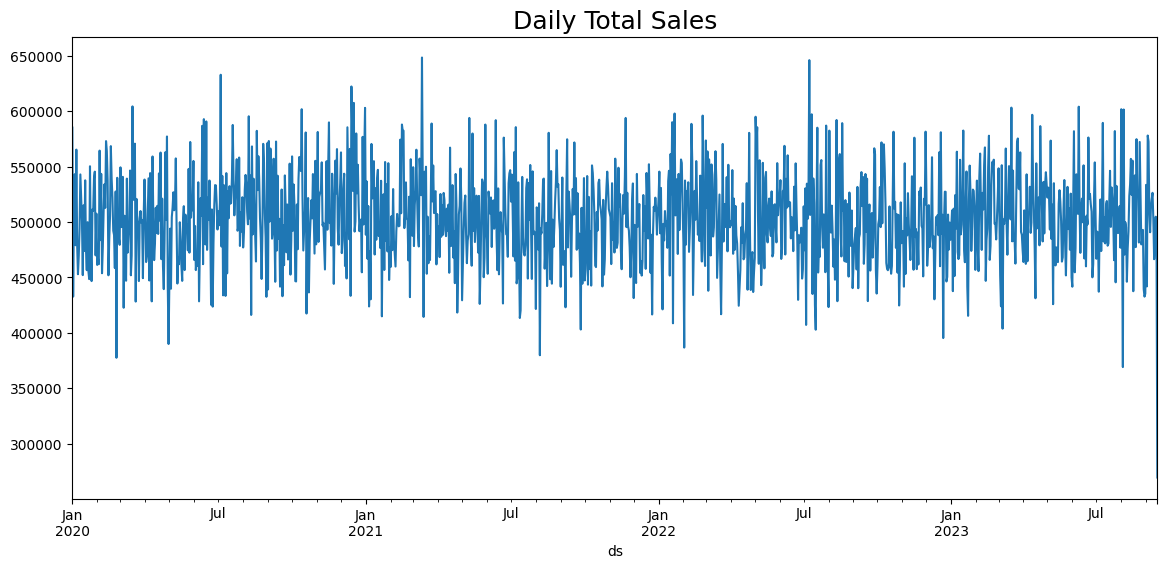

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=32860.757, Time=6.10 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=32624.762, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=32628.377, Time=3.15 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=32628.263, Time=1.52 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=39406.224, Time=0.07 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=32626.760, Time=2.05 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=32626.521, Time=0.51 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=32628.521, Time=1.43 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=32626.503, Time=0.37 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=32626.517, Time=0.20 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=32628.527, Time=0.55 sec

Best model:  ARIMA(0,0,0)(0,0,0)[7] intercept
Total fit time: 16.052 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:      

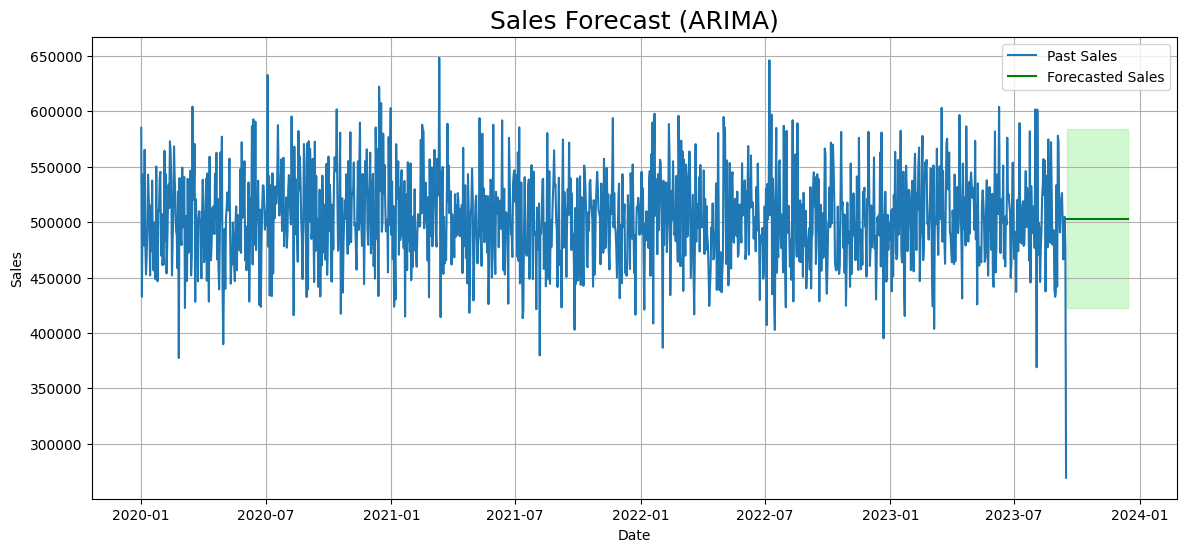

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np


print(f"NumPy version: {np.__version__}")


# Load your data

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Aggregate daily sales
sales_daily = df.groupby(df['Purchase Date'].dt.date)['Total Purchase Amount'].sum().reset_index()
sales_daily.columns = ['ds', 'y']
sales_daily['ds'] = pd.to_datetime(sales_daily['ds'])

# Set date as index
sales_daily.set_index('ds', inplace=True)

# Plot to check trends
sales_daily['y'].plot(figsize=(14, 6))
plt.title('Daily Total Sales', fontsize=18)
plt.show()

# --- Fit ARIMA Model ---

# Auto ARIMA (find best parameters automatically)
from pmdarima import auto_arima

# Find optimal (p,d,q) values
stepwise_model = auto_arima(
    sales_daily['y'],
    seasonal=True, m=7,   # m=7 for weekly seasonality; change if needed
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

# Summary of the model
print(stepwise_model.summary())

# Forecast the next 90 days
n_periods = 90
future_forecast, conf_int = stepwise_model.predict(n_periods=n_periods, return_conf_int=True)

# --- Plot the forecast ---
future_dates = pd.date_range(sales_daily.index[-1] + pd.Timedelta(days=1), periods=n_periods)

plt.figure(figsize=(14, 6))
plt.plot(sales_daily.index, sales_daily['y'], label='Past Sales')
plt.plot(future_dates, future_forecast, color='green', label='Forecasted Sales')
plt.fill_between(future_dates, conf_int[:, 0], conf_int[:, 1], color='lightgreen', alpha=0.4)
plt.title('Sales Forecast (ARIMA)', fontsize=18)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()




Streamlit App: Interactive ARIMA Forecast Visualization

In [13]:
!pip install streamlit pmdarima matplotlib pandas


In [14]:
import streamlit as st
import pandas as pd
from pmdarima import auto_arima
import matplotlib.pyplot as plt

st.set_page_config(page_title="📈 Sales Forecast", layout="wide")
st.title("📊 E-Commerce Sales Forecasting using Auto ARIMA")

# Load data
uploaded_file = st.file_uploader("Upload your cleaned CSV file", type="csv")

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
    df = df.sort_values("Purchase Date")

    # Aggregation
    daily_sales = df.groupby(df["Purchase Date"].dt.date)["Total Purchase Amount"].sum()
    monthly_sales = df.groupby(df["Purchase Date"].dt.to_period("M"))["Total Purchase Amount"].sum()

    daily_ts = pd.Series(daily_sales.values, index=pd.to_datetime(daily_sales.index))
    monthly_ts = pd.Series(monthly_sales.values, index=monthly_sales.index.to_timestamp())

    view = st.radio("Select Forecast View:", ("📅 Daily", "🗓️ Monthly"))

    if view == "📅 Daily":
        st.subheader("Daily Sales Forecast (Next 30 Days)")
        model = auto_arima(daily_ts, seasonal=False, stepwise=True, suppress_warnings=True)
        forecast = model.predict(n_periods=30)
        forecast_index = pd.date_range(start=daily_ts.index[-1] + pd.Timedelta(days=1), periods=30)
        forecast_series = pd.Series(forecast, index=forecast_index)

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(daily_ts, label="Observed")
        ax.plot(forecast_series, label="Forecast", color="orange")
        ax.set_title("Daily Forecast (ARIMA)")
        ax.legend()
        st.pyplot(fig)

    else:
        st.subheader("Monthly Sales Forecast (Next 6 Months)")
        model = auto_arima(monthly_ts, seasonal=False, stepwise=True, suppress_warnings=True)
        forecast = model.predict(n_periods=6)
        forecast_index = pd.date_range(start=monthly_ts.index[-1] + pd.offsets.MonthBegin(), periods=6, freq='MS')
        forecast_series = pd.Series(forecast, index=forecast_index)

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(monthly_ts, label="Observed")
        ax.plot(forecast_series, label="Forecast", color="orange")
        ax.set_title("Monthly Forecast (ARIMA)")
        ax.legend()
        st.pyplot(fig)

    st.success("Forecast generated successfully!")

else:
    st.info("👆 Upload your cleaned e-commerce dataset to begin.")


2025-05-01 14:30:40.249 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:30:40.255 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:30:40.753 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-05-01 14:30:40.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:30:40.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:30:40.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:30:40.762 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [17]:
! streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.29.2:8501

  Stopping...
^C


**2.2 Prophet Model**

In [18]:
!pip install prophet




Option B: Prophet Model (Facebook's tool, handles seasonality better)

Prophet is an open-source forecasting tool developed by Facebook's Core Data Science team. It's designed for time series data, particularly when there are strong seasonal patterns and historical data spanning several seasons. The model uses an additive approach, incorporating non-linear trends with yearly, weekly, and daily seasonality, as well as holiday effects.

ds → Purchase Dateds → Purchase Date

y → Sum of Total Purchase Amount by day

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtloz1zm/ihqnr83b.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtloz1zm/0je_0gny.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12649', 'data', 'file=/tmp/tmpwtloz1zm/ihqnr83b.json', 'init=/tmp/tmpwtloz1zm/0je_0gny.json', 'output', 'file=/tmp/tmpwtloz1zm/prophet_model7qhgw4wh/prophet_model-20250501144944.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:49:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:49:44 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


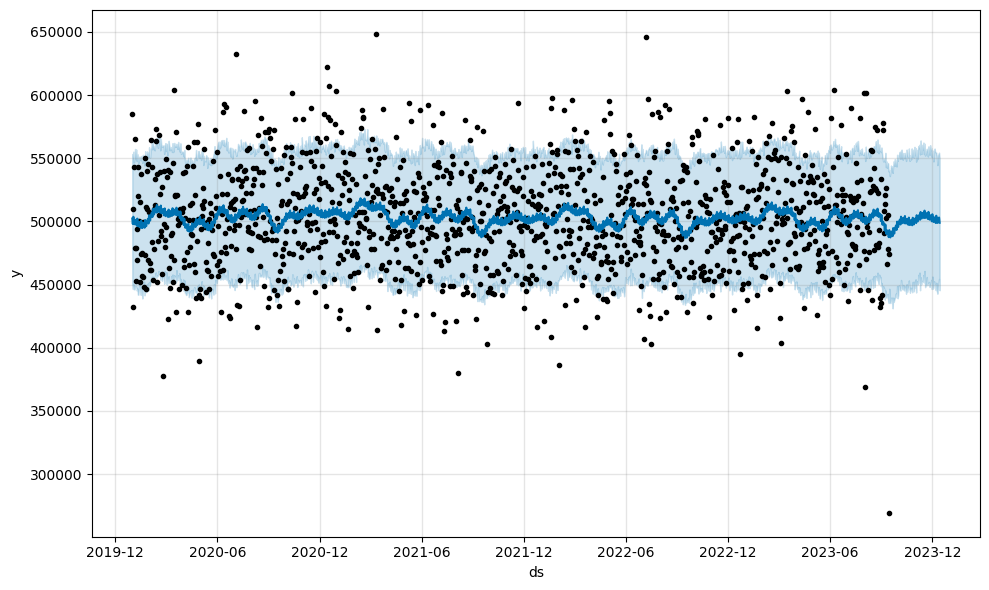

In [19]:
import pandas as pd
from prophet import Prophet

# Load your data

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Aggregate daily sales
sales_daily = df.groupby(df['Purchase Date'].dt.date)['Total Purchase Amount'].sum().reset_index()
sales_daily.columns = ['ds', 'y']
sales_daily['ds'] = pd.to_datetime(sales_daily['ds'])

# Fit Prophet
model = Prophet()
model.fit(sales_daily)

# Forecast the next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Plot
fig1 = model.plot(forecast)



The predicted sales (yhat)

The confidence interval (yhat_lower, yhat_upper)

Blue line = forecast

Light blue area = uncertainty intervals (confidence bounds)

1. Your Dataset
Sales are based on individual purchases recorded by date.

We have a timestamp (Purchase Date) and sales amount (Total Purchase Amount) — perfect for time series.

Likely multiple transactions per day, so we sum them daily for forecasting.

🔥 2. General Observations
No missing dates: But we’ll want to double-check — Prophet expects continuous time series (even if sales = 0).

Returns column exists: you could subtract returns from sales for more accurate net sales forecasting.

Seasonality might be strong: E-commerce often shows

Weekly patterns (weekends more sales?)

Yearly patterns (holidays like Black Friday, Christmas boosts?)

📈 3. What Prophet Will Capture
Trend: Are your sales growing over time? Declining? Stable?

Seasonality:

Weekly — people might shop more on weekends.

Yearly — holiday season spikes (Nov–Dec).

Holidays / Events: You can add major e-commerce events if you want even more accurate forecasting.



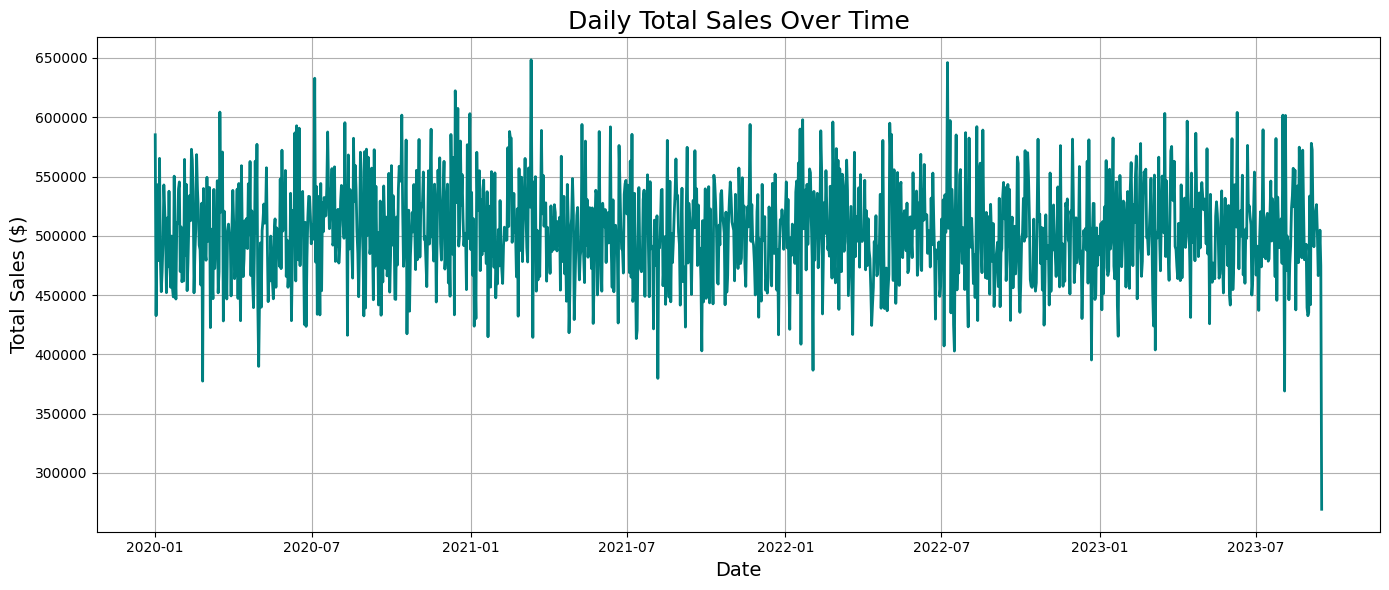

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Aggregate daily sales
sales_daily = df.groupby(df['Purchase Date'].dt.date)['Total Purchase Amount'].sum().reset_index()
sales_daily.columns = ['ds', 'y']
sales_daily['ds'] = pd.to_datetime(sales_daily['ds'])

# Plot the sales curve
plt.figure(figsize=(14, 6))
plt.plot(sales_daily['ds'], sales_daily['y'], color='teal', linewidth=2)
plt.title('Daily Total Sales Over Time', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Sales ($)', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()



Add seasonality (weekly, yearly)

Show holidays effects

Plot components separately (trends + seasonality)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtloz1zm/do0hhqjb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtloz1zm/5aqbf3mx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27210', 'data', 'file=/tmp/tmpwtloz1zm/do0hhqjb.json', 'init=/tmp/tmpwtloz1zm/5aqbf3mx.json', 'output', 'file=/tmp/tmpwtloz1zm/prophet_modeli0k_lwrp/prophet_model-20250501145024.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:50:24 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:50:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


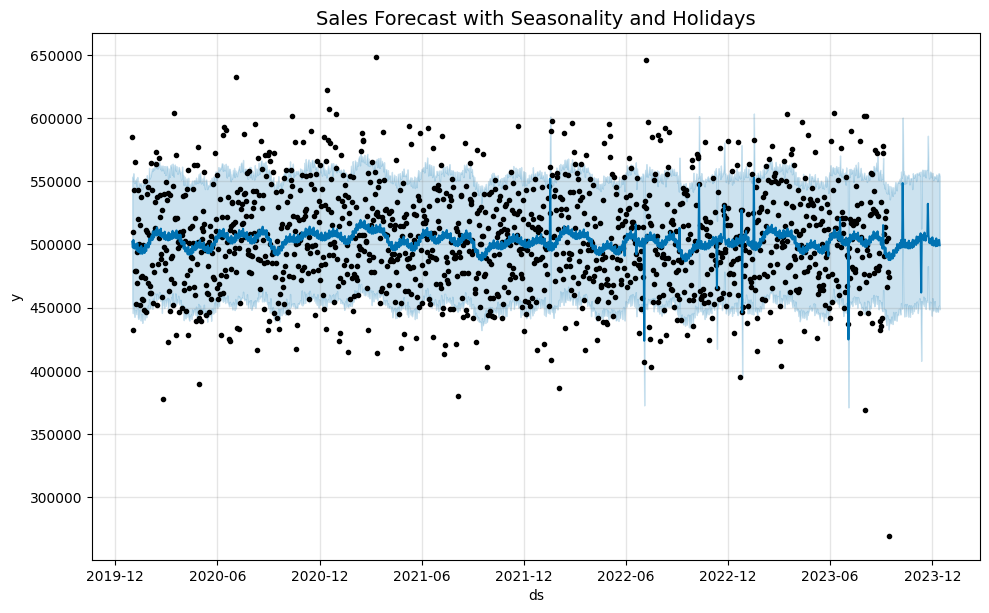

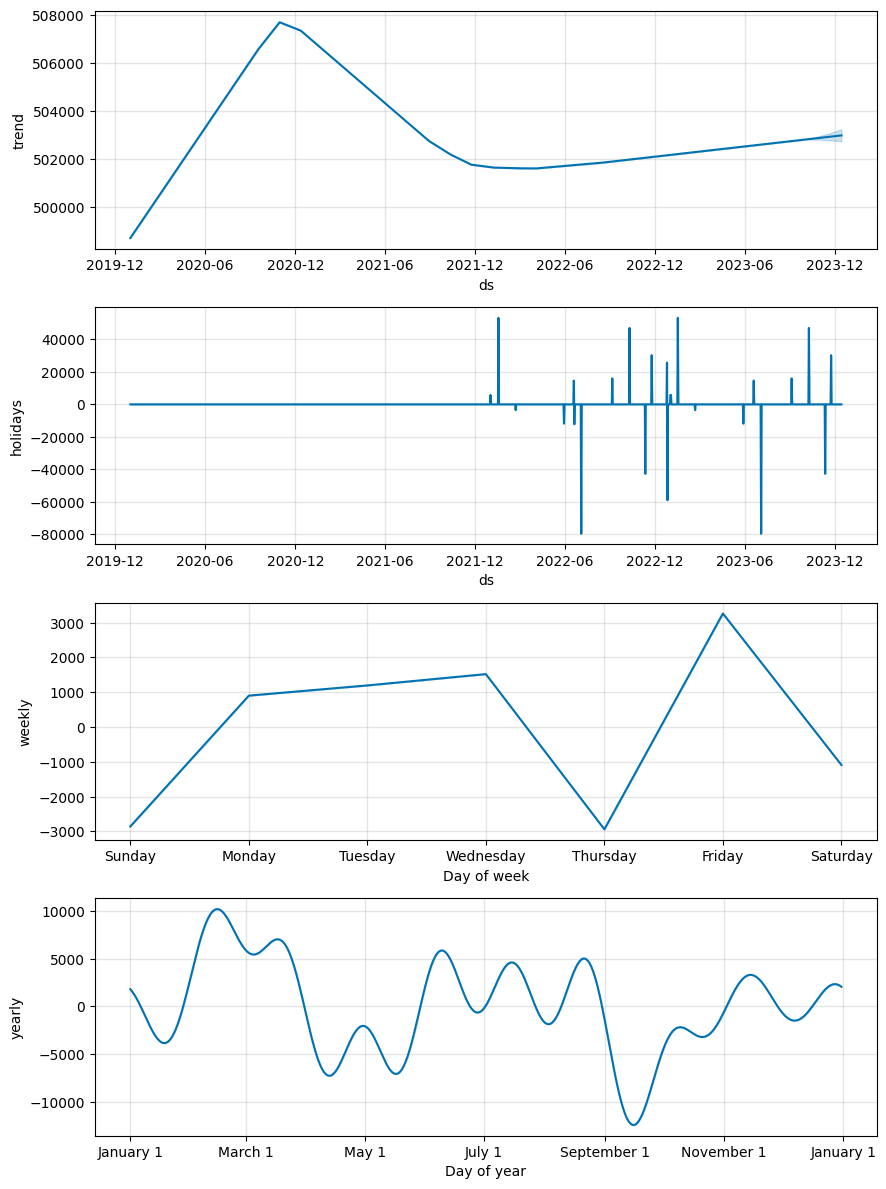

In [21]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load your data

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Aggregate daily sales
sales_daily = df.groupby(df['Purchase Date'].dt.date)['Total Purchase Amount'].sum().reset_index()
sales_daily.columns = ['ds', 'y']
sales_daily['ds'] = pd.to_datetime(sales_daily['ds'])

# Initialize Prophet with seasonality
model = Prophet(
    yearly_seasonality=True,  # Yearly pattern (e.g., holidays, seasons)
    weekly_seasonality=True,  # Weekly pattern (e.g., weekends boost sales)
    daily_seasonality=False   # (Only if you think intra-day patterns matter; usually false)
)

# --- Add holidays (optional) ---
from prophet.make_holidays import make_holidays_df

# Example: built-in holidays for US (adjust for your country if needed)
holidays = make_holidays_df(year_list=[2022, 2023, 2024], country='US')
model = Prophet(holidays=holidays)

# Fit the model
model.fit(sales_daily)

# Forecast the future
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# --- Plot full forecast ---
fig1 = model.plot(forecast)
plt.title('Sales Forecast with Seasonality and Holidays', fontsize=14)
plt.show()

# --- Plot trend + seasonal components ---
fig2 = model.plot_components(forecast)
plt.show()


Add Custom Holidays

If you know special shopping dates (e.g., Black Friday, Cyber Monday, Singles’ Day), you can add custom holidays too.

In [22]:
from pandas import DataFrame

special_days = DataFrame({
    'holiday': 'ecommerce_event',
    'ds': pd.to_datetime(['2024-11-29', '2024-12-02']),  # Black Friday, Cyber Monday
    'lower_window': 0,
    'upper_window': 1,  # Effect can spill into next day
})

model = Prophet(holidays=special_days)



In [23]:
!pip install --upgrade pmdarima

Compare Prophet and ARIMA

DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtloz1zm/ys1x0zyh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwtloz1zm/yh3diqk_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=98464', 'data', 'file=/tmp/tmpwtloz1zm/ys1x0zyh.json', 'init=/tmp/tmpwtloz1zm/yh3diqk_.json', 'output', 'file=/tmp/tmpwtloz1zm/prophet_modelhpt4pboh/prophet_model-20250501145125.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:51:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:51:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


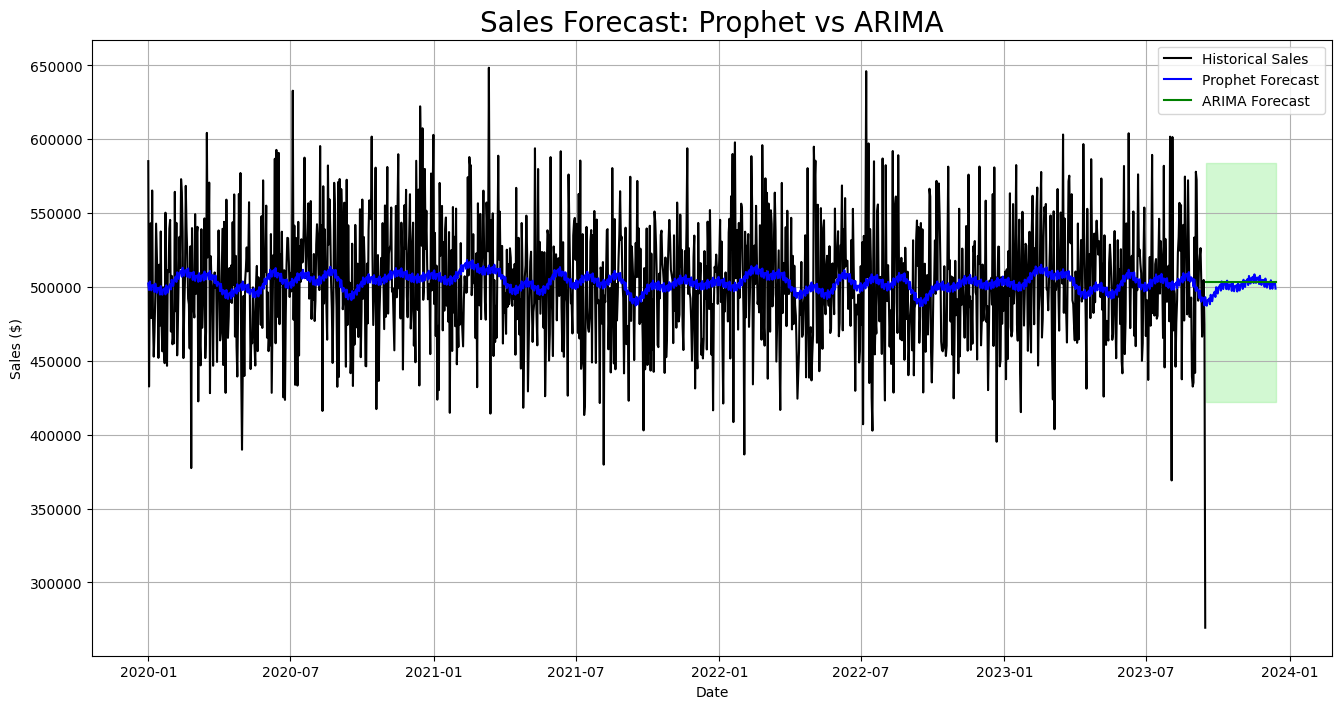

In [24]:

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

# Load data

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Aggregate daily sales
sales_daily = df.groupby(df['Purchase Date'].dt.date)['Total Purchase Amount'].sum().reset_index()
sales_daily.columns = ['ds', 'y']
sales_daily['ds'] = pd.to_datetime(sales_daily['ds'])

# ---- Prophet Forecast ----
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
prophet_model.fit(sales_daily)

future = prophet_model.make_future_dataframe(periods=90)
prophet_forecast = prophet_model.predict(future)

# ---- ARIMA Forecast ----
sales_arima = sales_daily.set_index('ds')['y']

stepwise_model = auto_arima(
    sales_arima,
    seasonal=True, m=7,
    trace=False,
    error_action='ignore',
    suppress_warnings=True
)

n_periods = 90
arima_forecast, conf_int = stepwise_model.predict(n_periods=n_periods, return_conf_int=True)
future_dates_arima = pd.date_range(sales_arima.index[-1] + pd.Timedelta(days=1), periods=n_periods)

# ---- Plot Side-by-Side ----
plt.figure(figsize=(16, 8))

# Plot Prophet
plt.plot(sales_daily['ds'], sales_daily['y'], label='Historical Sales', color='black')
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast', color='blue')

# Plot ARIMA
plt.plot(future_dates_arima, arima_forecast, label='ARIMA Forecast', color='green')
plt.fill_between(future_dates_arima, conf_int[:, 0], conf_int[:, 1], color='lightgreen', alpha=0.4)

# Decorations
plt.title('Sales Forecast: Prophet vs ARIMA', fontsize=20)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True)
plt.show()





In [ ]:
                                                ####### The End  #########

